<a href="https://colab.research.google.com/github/comethrusws/Sentiment_Analysis_nlp/blob/main/fellowship_sentiment_analysis_challenge_basab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()


KeyboardInterrupt: 

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# download IMDB Dataset
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
 51% 13.0M/25.7M [00:00<00:00, 133MB/s]
100% 25.7M/25.7M [00:00<00:00, 168MB/s]


In [ ]:
import pandas as pd
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
import warnings
from tqdm import tqdm

spacy.require_gpu()

warnings.filterwarnings('ignore')

In [ ]:
# ds download
DATA_PATH = "/content/imdb-dataset-of-50k-movie-reviews.zip"

# inspectign our dataset
def load_data(path):
    df = pd.read_csv(path)
    print(f"Dataset Shape: {df.shape}")
    print("\nSample Reviews:")
    print(df.head())
    print("\nClass Distribution:")
    print(df['sentiment'].value_counts())
    return df

In [ ]:
#preprocessing our data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove non-alphabetic characters
    return text

def preprocess_reviews(df, nlp):
    tqdm.pandas(desc="Processing Reviews")
    df['processed_review'] = df['review'].progress_apply(lambda x: preprocess_text(x, nlp))
    return df

def preprocess_text(text, nlp):
    text = clean_text(text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.is_alpha and len(token.text) > 2]
    return ' '.join(tokens)


In [ ]:
#visualise data
def plot_review_length_distribution(df):
    df['review_length'] = df['processed_review'].str.split().str.len()
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='sentiment', y='review_length', data=df)
    plt.title('Review Lengths by Sentiment')
    plt.show()

In [ ]:
# train and evaluate logistic regression
def train_logistic_regression(X_train, X_test, y_train, y_test):
    vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    print("Vectorizing training data...")
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)
    print("Vectorization completed!")

    model = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1, random_state=42)
    print("Training Logistic Regression model...")
    model.fit(X_train_vectorized, y_train)
    print("Model training completed!")

    # Evaluate
    y_pred = model.predict(X_test_vectorized)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return vectorizer, model

In [ ]:
# Sentiment analysis with Transformers
def transformers_sentiment_analysis():
    sentiment_analyzer = pipeline("sentiment-analysis", device=0)
    sample_review = """
    This movie was absolutely fantastic! The acting was superb and the
    storyline kept me engaged throughout. Definitely worth watching!
    """
    result = sentiment_analyzer(sample_review)
    print("\nSample Prediction using Transformers:")
    print(f"Text: {sample_review}")
    print(f"Sentiment: {result[0]['label']}")
    print(f"Confidence: {result[0]['score']:.2f}")


Dataset Shape: (50000, 2)

Sample Reviews:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Loading SpaCy model...
Preprocessing reviews with SpaCy...


Processing Reviews: 100%|██████████| 50000/50000 [14:47<00:00, 56.33it/s]


Preprocessing completed!


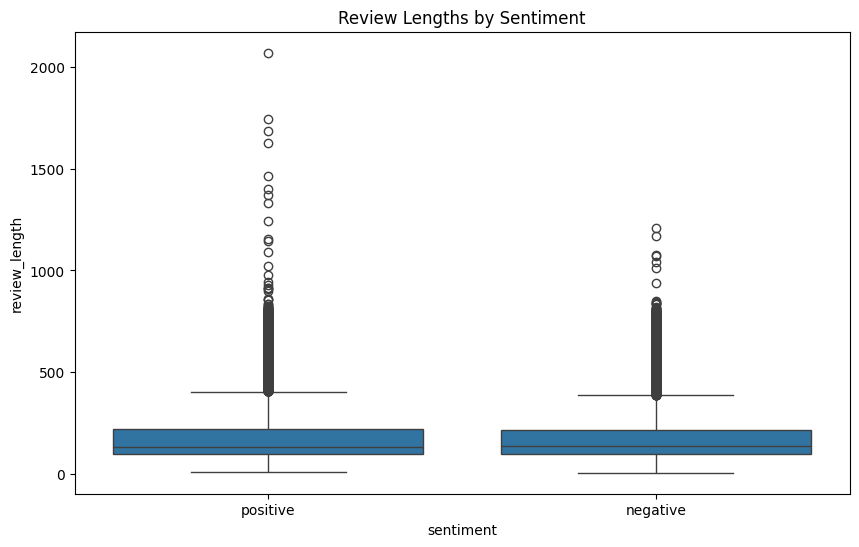

Vectorizing training data...
Vectorization completed!
Training Logistic Regression model...
Model training completed!

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.92      0.91      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



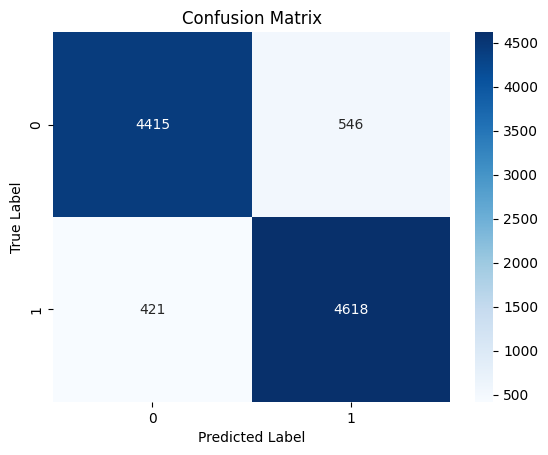

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0



Sample Prediction using Transformers:
Text: 
    This movie was absolutely fantastic! The acting was superb and the 
    storyline kept me engaged throughout. Definitely worth watching!
    
Sentiment: POSITIVE
Confidence: 1.00


In [ ]:
def main():
    df = load_data(DATA_PATH)

    # init spacy
    print("Loading SpaCy model...")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # Disable unnecessary components

    print("Preprocessing reviews with SpaCy...")
    df = preprocess_reviews(df, nlp)
    print("Preprocessing completed!")

    # visualise data
    plot_review_length_distribution(df)

    # prep data
    df['sentiment_binary'] = (df['sentiment'] == 'positive').astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        df['processed_review'],
        df['sentiment_binary'],
        test_size=0.2,
        random_state=42
    )

    #model
    vectorizer, model = train_logistic_regression(X_train, X_test, y_train, y_test)

    transformers_sentiment_analysis()


if __name__ == "__main__":
    main()